In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import sys
sys.path.append('/kaggle/input/entransformer-datasets')
import torch
from torch.utils.data import DataLoader

In [2]:
%%capture
!pip install darts==0.39.0
!pip install gluonts
!pip install lightning

### Deterministic Seed Setting



In [3]:
import os
import random
import numpy as np
import torch
import cv2
from transformers import set_seed
from datasets import disable_progress_bar
# VERY TOP OF NOTEBOOK, before importing torch/darts/lightning
import os
os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
# optional for debugging only:
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

class Deterministic:
    def __init__(self):
        pass

    def init_all(self, seed=0, disable_list=['cuda_block']):
        random.seed(seed)
        os.environ['PYTHONHASHSEED'] = str(seed)
        os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
        if 'cuda_block' not in disable_list: # stuck when train deberta
            os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
        os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        if 'torch_deter_algo' not in disable_list: # consumn more gpu sometimes
            torch.use_deterministic_algorithms(True, warn_only=True)
        set_seed(seed)
        cv2.setRNGSeed(seed)
        disable_progress_bar()

deterministic = Deterministic()

### Importing Libraries

In [7]:
import torch
import torch.nn as nn
import pandas as pd
from typing import Tuple, Optional
from darts import TimeSeries
from darts.models.forecasting.transformer_model import TransformerModel, _TransformerModule
from darts.metrics import mae, rmse, smape, mase, rmsse
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler

## Data Specific Params

In [5]:
dataset_name = "electricity_nips"

In [6]:
PRED_LEN = 24
LAGS = (1, 24, 168)

## Importing Data and Formatting

In [8]:
import numpy as np
import pandas as pd

from gluonts.dataset.repository.datasets import get_dataset
from gluonts.dataset.multivariate_grouper import MultivariateGrouper

from darts import TimeSeries

def gluonts_item_to_darts_mv(item, freq: str) -> TimeSeries:
    # GluonTS start is often a pandas Period; convert safely
    start = item["start"].to_timestamp() if hasattr(item["start"], "to_timestamp") else pd.Timestamp(item["start"])

    # GluonTS multivariate target is typically shape (D, T)
    target = np.asarray(item["target"])
    if target.ndim != 2:
        raise ValueError(f"Expected multivariate target with ndim=2, got shape {target.shape}")

    values = target.T  # Darts expects (T, D)
    times = pd.date_range(start=start, periods=values.shape[0], freq=freq)
    cols = [f"dim_{i}" for i in range(values.shape[1])]

    return TimeSeries.from_times_and_values(times, values, columns=cols)

# Load dataset
ds = get_dataset(dataset_name, regenerate=False)
freq = ds.metadata.freq

# Determine number of rolling test windows (should be 7 for solar_nips)
train_list = list(ds.train)
test_list  = list(ds.test)
num_test_dates = len(test_list) // len(train_list)   # e.g., 959//137 = 7

# Group into multivariate series (like their code)
target_dim = int(ds.metadata.feat_static_cat[0].cardinality)  # 137 for solar
train_grouper = MultivariateGrouper(max_target_dim=target_dim)
test_grouper  = MultivariateGrouper(num_test_dates=num_test_dates, max_target_dim=target_dim)

train_mv_items = list(train_grouper(train_list))   # usually 1 item
test_mv_items  = list(test_grouper(test_list))     # usually num_test_dates items (7)

train_ts = gluonts_item_to_darts_mv(train_mv_items[0], freq)
test_ts_list = [gluonts_item_to_darts_mv(it, freq) for it in test_mv_items]  # len=7

In [11]:
test_ts_list[2].shape

(4048, 370, 1)

In [9]:
from darts.dataprocessing.transformers import Scaler

y_scaler = Scaler()                     # StandardScaler-like wrapper
train_y_sc = y_scaler.fit_transform(train_ts)

import numpy as np
from darts import TimeSeries, concatenate

def lag_covs_from_scaled_target(ts_sc: TimeSeries, lags=(1,24,168)) -> TimeSeries:
    shifted = []
    for L in lags:
        s = ts_sc.shift(L).with_columns_renamed(
            ts_sc.components, [f"{c}_lag{L}" for c in ts_sc.components]
        )
        shifted.append(s)

    common = shifted[0]
    for s in shifted[1:]:
        common = common.slice_intersect(s)
    shifted = [s.slice_intersect(common) for s in shifted]
    return concatenate(shifted, axis=1)

def fourier_from_index(idx) -> TimeSeries:
    hour = idx.hour.to_numpy()
    dow  = idx.dayofweek.to_numpy()
    X = np.vstack([
        np.sin(2*np.pi*hour/24.0),
        np.cos(2*np.pi*hour/24.0),
        np.sin(2*np.pi*dow/7.0),
        np.cos(2*np.pi*dow/7.0),
    ]).T
    return TimeSeries.from_times_and_values(idx, X, columns=["h_sin","h_cos","dow_sin","dow_cos"])

def dim_indicator_norm(idx, D: int) -> TimeSeries:
    v = (np.arange(D, dtype=np.float32) / (D-1)).astype(np.float32)  # 0..1
    X = np.tile(v, (len(idx), 1))
    cols = [f"dim_id_{i}" for i in range(D)]
    return TimeSeries.from_times_and_values(idx, X, columns=cols)

def build_past_covs_552(ts_sc: TimeSeries, lags=(1,24,168)) -> TimeSeries:
    lag_covs = lag_covs_from_scaled_target(ts_sc, lags)
    idx = lag_covs.time_index
    time_covs = fourier_from_index(idx)
    dim_covs  = dim_indicator_norm(idx, ts_sc.width)
    return concatenate([lag_covs, dim_covs, time_covs], axis=1)


def ts_upto(ts, end_time):
    # Newer Darts
    if hasattr(ts, "slice_end"):
        return ts.slice_end(end_time)
    # Some versions
    if hasattr(ts, "drop_after"):
        return ts.drop_after(end_time)
    if hasattr(ts, "split_after"):
        return ts.split_after(end_time)[0]
    # Works in basically all versions
    return ts.slice(ts.start_time(), end_time)

In [10]:
import pandas as pd
from gluonts.dataset.repository.datasets import get_dataset

def gluon_to_wide_df(dataset):
    series_list = []
    
    for i, entry in enumerate(dataset):
        # 1. Create the time index using the start date and frequency
        idx = pd.date_range(
            start=entry["start"].to_timestamp(), 
            periods=len(entry["target"]), 
            freq=entry["start"].freqstr
        )
        
        # 2. Create a Series for each node, named by its index (0 to 136)
        series = pd.Series(entry["target"], index=idx, name=f"node_{i}")
        series_list.append(series)
    
    # 3. Concatenate all series into one DataFrame (T x N)
    return pd.concat(series_list, axis=1)

# Usage:
dataset = get_dataset(dataset_name, regenerate=False)
df_train = gluon_to_wide_df(dataset.train)

def get_7_test_windows(dataset, num_nodes=137):
    all_series = []
    
    # 1. Convert everything to a list of Series first
    for entry in dataset:
        idx = pd.date_range(
            start=entry["start"].to_timestamp(), 
            periods=len(entry["target"]), 
            freq=entry["start"].freqstr
        )
        # Give them a generic name for now
        all_series.append(pd.Series(entry["target"], index=idx))
    
    # 2. Split the list into 7 chunks of 137
    # This assumes the order is [Node0_W1, Node1_W1... Node136_W1, Node0_W2...]
    num_windows = len(all_series) // num_nodes
    windows = []
    
    for w in range(num_windows):
        start_idx = w * num_nodes
        end_idx = (w + 1) * num_nodes
        
        # Grab 137 series and concat them side-by-side
        window_df = pd.concat(all_series[start_idx:end_idx], axis=1)
        
        # Rename columns to node_0, node_1... node_136
        window_df.columns = [f"node_{i}" for i in range(num_nodes)]
        windows.append(window_df)
        
    return windows

# Execute
test_windows = get_7_test_windows(dataset.test, num_nodes=370)

In [11]:
df_train

,node_0,node_1,node_2,node_3,node_4,node_5,node_6,node_7,node_8,node_9,...,node_360,node_361,node_362,node_363,node_364,node_365,node_366,node_367,node_368,node_369
2014-01-01 00:00:00,NaN,175.531921,31.993204,56.265984,47.902317,27.983105,209.358688,236.563446,6.930185,1161.392456,...,33.882782,7.200886,127.659576,90.614883,225.498398,NaN,1037.463989,90.314903,114.575340,47.912006
2014-01-01 01:00:00,NaN,164.893616,31.285391,55.200340,49.624294,27.719112,200.783005,236.570999,6.930185,638.185669,...,30.769230,6.462334,119.922630,87.702263,226.302246,NaN,1052.593628,93.010750,120.746574,46.234154
2014-01-01 02:00:00,NaN,154.787231,31.568516,55.413471,44.458359,27.719112,191.275162,246.397278,6.930185,573.839661,...,34.981686,9.231906,108.317215,84.466019,206.993576,NaN,946.685852,90.318741,126.232880,47.539150
2014-01-01 03:00:00,NaN,137.234039,29.728199,56.692242,39.292423,27.719112,180.462341,236.563446,6.673512,565.400818,...,30.402931,9.047267,102.030945,82.686081,208.609329,NaN,996.397705,86.470818,124.174660,53.504848
2014-01-01 04:00:00,NaN,138.297867,29.869762,55.200340,37.883533,27.719112,186.800888,232.787003,6.930185,558.016907,...,28.205128,8.493353,90.425529,86.084145,202.162384,NaN,1034.582153,76.866356,115.263702,52.199852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-08-31 20:00:00,100.230415,122.340424,86.919594,58.184143,36.318096,38.542767,559.097717,667.273438,17.710472,4990.506348,...,293.223450,76.624817,146.518372,363.430420,706.535339,79.769737,2247.838623,173.329498,324.017120,127.143921
2014-08-31 21:00:00,95.046082,148.936172,83.097397,58.823528,45.554165,39.070751,525.913513,635.460754,17.710472,3943.038086,...,195.054947,78.286560,170.696320,361.974121,668.633423,79.358551,2292.507324,167.949310,318.178070,117.449661
2014-08-31 22:00:00,71.428574,128.723404,63.703285,60.102303,43.519100,39.334740,435.309479,511.072510,15.143737,3237.341797,...,133.699631,64.992615,168.278534,288.834961,625.104492,79.358551,2206.051758,139.512283,238.143829,90.231171
2014-08-31 23:00:00,52.995392,129.787231,45.583241,57.757885,45.241077,39.070751,413.870239,283.429016,13.347023,1869.198364,...,122.344322,60.930576,147.969055,246.440125,508.802246,72.779602,2267.291016,111.459297,137.886993,66.741241


np.False_

In [10]:
df_train.shape

(5833, 370)

In [19]:
test_ts_list[3]

,dim_0,dim_1,dim_2,dim_3,dim_4,...,dim_365,dim_366,dim_367,dim_368,dim_369
2014-03-19 09:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000
2014-03-19 10:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000
2014-03-19 11:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000
2014-03-19 12:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000
2014-03-19 13:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
2014-09-04 20:00:00,134.216583,148.936172,77.718010,99.104858,98.622414,...,74.424339,2963.977051,182.173584,322.301361,118.195374
2014-09-04 21:00:00,108.870964,167.553192,77.718010,96.547318,93.769569,...,78.536186,3011.527344,174.873276,311.308228,114.466812
2014-09-04 22:00:00,62.211983,147.340424,63.278595,86.743393,93.613022,...,73.190788,3283.861572,142.200455,225.010269,86.502609
2014-09-04 23:00:00,59.331799,135.638290,45.300114,65.643646,93.456482,...,69.078949,3203.890381,116.067589,142.684937,70.842651


In [20]:
test_windows[3]

,node_0,node_1,node_2,node_3,node_4,node_5,node_6,node_7,node_8,node_9,...,node_360,node_361,node_362,node_363,node_364,node_365,node_366,node_367,node_368,node_369
2014-03-22 09:00:00,85.829491,130.851059,68.657982,86.743393,81.089546,29.567055,481.357208,543.557373,6.930185,1137.130859,...,77.838829,21.233383,106.866539,228.478958,600.112549,57.976974,1874.639771,156.036865,281.770538,82.401192
2014-03-22 10:00:00,110.599075,152.659576,66.251419,92.071609,83.594238,29.303062,475.018646,618.043823,6.930185,1502.109741,...,102.930405,43.205318,107.350098,230.906143,613.818298,64.967102,2043.227661,175.637482,297.222595,88.180466
2014-03-22 11:00:00,114.055298,163.297867,74.745186,91.858482,85.942390,29.303062,471.290070,602.129883,6.930185,1684.599121,...,159.706955,43.574593,103.481628,257.119751,587.202576,74.424339,2059.798340,187.553757,302.376709,88.926178
2014-03-22 12:00:00,99.078339,166.489365,74.886749,95.268539,89.699440,29.303062,477.255768,633.187317,6.930185,2412.447266,...,149.267395,54.098965,103.965187,252.588989,582.363342,83.881577,1972.622437,191.394012,321.270538,87.248322
2014-03-22 13:00:00,145.161285,151.063828,70.356735,92.284737,50.407013,29.831045,484.153625,606.684265,6.930185,2787.974609,...,149.450546,64.069427,92.359764,250.000000,565.442139,62.500000,1777.377563,199.470047,288.636993,88.739746
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-09-04 20:00:00,134.216583,148.936172,77.718010,99.104858,98.622414,38.278774,623.042480,689.229614,14.373716,4379.747070,...,281.501831,62.223042,140.232101,288.673126,721.848877,74.424339,2963.977051,182.173584,322.301361,118.195374
2014-09-04 21:00:00,108.870964,167.553192,77.718010,96.547318,93.769569,39.070751,570.842651,634.705444,13.090349,3412.447266,...,193.772888,63.884785,137.330750,280.097076,671.864929,78.536186,3011.527344,174.873276,311.308228,114.466812
2014-09-04 22:00:00,62.211983,147.340424,63.278595,86.743393,93.613022,36.694824,506.338562,522.416931,11.550308,3079.114014,...,134.432236,57.791729,130.077362,263.268616,616.229919,73.190788,3283.861572,142.200455,225.010269,86.502609
2014-09-04 23:00:00,59.331799,135.638290,45.300114,65.643646,93.456482,36.430836,429.530212,294.018127,11.550308,1774.261597,...,118.864471,48.005909,118.471954,224.919098,509.598083,69.078949,3203.890381,116.067589,142.684937,70.842651


In [11]:
import numpy as np
import pandas as pd
from darts import TimeSeries

def impute_seasonal_mean(df, m: int) -> TimeSeries:
    """
    Imputes NaN values in a Darts TimeSeries of shape T x N using the seasonal mean.
    
    Parameters:
    - ts: The original Darts TimeSeries object.
    - m: The seasonal period (e.g., 12 for monthly data, 24 for hourly data).
    
    Returns:
    - A new TimeSeries with NaN values imputed, preserving original metadata.
    """
    
    # 2. Create a seasonal indicator array (0 to m-1) 
    # This works reliably because Darts enforces a strictly regular time index
    season_indicator = np.arange(len(df)) % m
    
    # 3. Group by the season, calculate the mean per column, and fill NaNs
    # transform('mean') broadcasts the group means back to the original index shape
    df_imputed = df.fillna(df.groupby(season_indicator).transform('mean'))
    
    # 4. Inject the values back into the TimeSeries to retain metadata
    return df_imputed


df_train = impute_seasonal_mean(df_train, m=24)

### Metric

In [12]:
def crps(preds, targets, quantiles=(np.arange(20) / 20.0)[1:]):
    """
    preds: (B, N, T, D) or (B, N, T)
    targets: (B, T, D) or (B, T)
    """
    x = np.quantile(preds, quantiles, axis=1, method="nearest")  # -> (Q, B, T, D) or (Q, B, T)
    quantiles = np.expand_dims(quantiles, axis=list(range(1, len(preds.shape))))  # (Q,1,1,1)
    loss = 2 * np.sum(np.abs((x - targets) * ((targets <= x) - quantiles)), axis=2)  # sum over T
    return loss.mean() / np.abs(targets).sum(axis=1).mean()

def crps_sum(preds, targets, quantiles=(np.arange(20) / 20.0)[1:], frequency = 'D'):
    # preds: (B, N, T, D)
    # targets: (B, T, D)

    preds_sum = preds.sum(axis=-1)      # (B, N, T)
    targets_sum = targets.sum(axis=-1)  # (B, T)

    return crps(preds_sum, targets_sum, quantiles=quantiles)


def get_crps(model, test_windows, y_scaler, pred_len=24, lags=(1, 24, 168), num_samples=100, seed = 42, std = None):
    all_forecasts = []
    all_targets = []

    for i, window_df in enumerate(test_windows):
        full_ts = TimeSeries.from_dataframe(window_df).astype(np.float32)
        full_sc = y_scaler.transform(full_ts).astype(np.float32)
        full_pc = build_past_covs_552(full_sc, lags=lags).astype(np.float32)

        full_sc = full_sc.slice_intersect(full_pc)
        full_ts = full_ts.slice_intersect(full_sc)
        full_pc = full_pc.slice_intersect(full_sc)

        past_true_sc = full_sc[:-pred_len]
        gt_future    = full_ts[-pred_len:]
        
        forecast_start = gt_future.start_time()
        pc_past = ts_upto(full_pc, forecast_start)

        model.model.encoder[0].reset_seed(seed)
        if std is not None:
            model.model.encoder[0].reset_std(std)
        
        fc_sc = model.predict(
            n=pred_len,
            series=past_true_sc,
            past_covariates=pc_past,
            num_samples=num_samples,
            verbose = False,
            random_state = 1456445
        )

        fc = y_scaler.inverse_transform(fc_sc)
        fc = fc.with_values(np.clip(fc.all_values(), a_min=0, a_max=None))

        assert fc.time_index.equals(gt_future.time_index), \
            f"Forecast index mismatch in window {i}"

        all_forecasts.append(fc.all_values(copy=False))
        all_targets.append(gt_future.all_values(copy=False))

        # print(f"Processed window {i+1}/{len(test_windows)}")

    stacked_forecasts = np.stack(all_forecasts, axis=0)      # (B, T, D, N)
    preds_reshaped = np.transpose(stacked_forecasts, (0, 3, 1, 2))  # (B, N, T, D)

    stacked_targets = np.stack(all_targets, axis=0)          # (B, T, D, 1)
    targets_reshaped = np.squeeze(stacked_targets, axis=-1)  # (B, T, D)

    return crps_sum(preds_reshaped, targets_reshaped)

## Model

In [13]:
def energy_score_loss(samples: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """
    samples: (M, batch, len, dim) - M stochastic samples
    target: (batch, len, dim) - Ground truth
    """
    M = samples.size(0)
    
    # Term 1: Mean distance to target E[||Y - y||]
    # Resulting shape: (batch, len)
    dist_to_target = torch.linalg.norm(samples - target.unsqueeze(0), dim=-1).mean(0)
    
    # Term 2: Mean pairwise distance between samples 0.5 * E[||Y - Y'||]
    # Flatten samples to (M, batch*len, dim) for efficient pairwise calculation
    s = samples.reshape(M, -1, samples.size(-1))
    # (M, 1, BL, D) - (1, M, BL, D) -> (M, M, BL, D)
    diff = s.unsqueeze(1) - s.unsqueeze(0)
    pairwise_dist = torch.linalg.norm(diff, dim=-1).mean(dim=(0, 1))
    dist_samples = pairwise_dist.view(target.size(0), target.size(1))
    
    # Final Energy Score (mean over batch and time)
    loss = dist_to_target - 0.5 * dist_samples
    return loss.mean()


import torch
import torch.nn as nn

class GaussianNoise(nn.Module):
    def __init__(self, std: float, seed: int | None = None):
        super().__init__()
        self.std = std
        self.seed = seed
        self._gen = None
        self._gen_device = None

    def _get_generator(self, device: torch.device):
        if self._gen is None or self._gen_device != device:
            self._gen = torch.Generator(device=device)
            self._gen_device = device
            if self.seed is not None:
                self._gen.manual_seed(self.seed)
        return self._gen

    def reset_seed(self, seed: int | None = None):
        if seed is not None:
            self.seed = seed
        if self.seed is None:
            raise ValueError("No seed set for this module.")
        if self._gen is not None:
            self._gen.manual_seed(self.seed)

    def reset_std(self, std: float | None = None):
        self.std = std

    def forward(self, x: torch.Tensor):
        g = self._get_generator(x.device)
        noise = torch.randn(
            x.shape,
            dtype=x.dtype,
            device=x.device,
            generator=g,
        )
        return x + noise * self.std


class UniformNoise(nn.Module):
    def __init__(self, std: float, seed: int | None = None):
        super().__init__()
        self.std = std
        self.seed = seed
        self._gen = None
        self._gen_device = None

    def _get_generator(self, device: torch.device):
        if self._gen is None or self._gen_device != device:
            self._gen = torch.Generator(device=device)
            self._gen_device = device
            if self.seed is not None:
                self._gen.manual_seed(self.seed)
        return self._gen

    def reset_seed(self, seed: int | None = None):
        if seed is not None:
            self.seed = seed
        if self.seed is None:
            raise ValueError("No seed set for this module.")
        if self._gen is not None:
            self._gen.manual_seed(self.seed)

    def reset_std(self, std: float | None = None):
        self.std = std

    def forward(self, x: torch.Tensor):
        g = self._get_generator(x.device)
        noise = torch.rand(
            x.shape,
            dtype=x.dtype,
            device=x.device,
            generator=g,
        )
        return x + (2 * self.std) * noise - self.std



class EnTransformerModule(_TransformerModule):
    def __init__(self, input_size, output_size, 
            nr_params, *args, num_samples_engression=10, noise_dist="gaussian", noise_std=0.1, **kwargs):
        super().__init__(input_size=input_size, 
            output_size=output_size, 
            nr_params=nr_params, *args, **kwargs)
        
        self.M = num_samples_engression
        self.noise_std = noise_std
        self.noise_dist = noise_dist
        
        # Inject noise at the input of the encoder (adds to input sequence)
        # self.encoder is usually a nn.Linear mapping input_dim to d_model
        if self.noise_dist == "gaussian":
            self.encoder = nn.Sequential(
                GaussianNoise(self.noise_std, 42),
                self.encoder
            )
        elif self.noise_dist == "uniform":
            self.encoder = nn.Sequential(
                UniformNoise(self.noise_std, 42),
                self.encoder
            )
        else:
            raise ValueError("noise_dist must be either `gaussian` or `uniform`.")
            

    def forward(self, x_in: tuple, *args, **kwargs):
        """Intercepts data during prediction to ensure float32."""
        x_in_float = tuple(
            t.float() if isinstance(t, torch.Tensor) and torch.is_floating_point(t) else t 
            for t in x_in
        )
        return super().forward(x_in_float, *args, **kwargs)

    def training_step(self, batch, batch_idx):
        # Unpack the 7-element batch
        past_target = batch[0]
        past_covs = batch[1]
        static_covs = batch[4]
        future_target = batch[-1]
        
        batch_size = future_target.size(0)

        # Normalize past and future targets
        past_target_norm = past_target 
        future_target_norm = future_target 

        # Expand inputs M times
        past_target_m = past_target_norm.repeat_interleave(self.M, dim=0)
        
        # Handle Covariates: Darts concatenates covariates to the target 
        # along the feature dimension (dim=2) before calling _create_transformer_inputs
        if past_covs is not None:
            past_covs_m = past_covs.repeat_interleave(self.M, dim=0)
            # Combine target and covariates into a single tensor
            data_m = torch.cat([past_target_m, past_covs_m], dim=2)
        else:
            data_m = past_target_m

        # Construct the input for the @io_processor decorated forward pass
        # It expects: (data_tensor, future_covariates, static_covariates)
        # We need to repeat these as well
        fut_covs_m = batch[3].repeat_interleave(self.M, dim=0) if batch[3] is not None else None
        static_covs_m = static_covs.repeat_interleave(self.M, dim=0) if static_covs is not None else None
        data_m = data_m.float()
        #fut_covs_m = fut_covs_m.float()
        #static_covs_m = static_covs_m.float()
        x_expanded = (data_m, fut_covs_m, static_covs_m)

        # Forward pass
        # Now 'data' is a Tensor, so data.permute(1, 0, 2) will work
        y_hat_raw = self(x_expanded) # (BM, T, D)
        
        # Reshape for Energy Score
        samples = y_hat_raw.view(batch_size, self.M, y_hat_raw.shape[1], y_hat_raw.shape[2]) # (B, M, T, D)
        samples = samples.permute(1, 0, 2, 3) # (M, B, T, D)
        
        
        loss = energy_score_loss(samples, future_target_norm)
        
        self.log("energy_score_train_loss", loss, prog_bar=True, on_epoch=True)
        return loss



# 4. Custom Darts Model Class
class EnTransformerModel(TransformerModel):
    def __init__(self, input_chunk_length, output_chunk_length, *args, num_samples_engression: int = 10, noise_dist='gaussian', noise_std: float = 0.1, random_state = 23, **kwargs):
        """
        Darts Transformer implementation with Engression.
        
        Parameters
        ----------
        num_samples_engression
            Number of samples (M) used to compute the Energy Score loss during training.
        noise_std
            Standard deviation of the Gaussian noise added to the input sequence.
        """
        
        self.num_samples_engression = num_samples_engression
        self.noise_std = noise_std
        self.noise_dist = noise_dist
        #self.noise_dist = noise_dist
        super().__init__(input_chunk_length=input_chunk_length,
                         output_chunk_length=output_chunk_length,
                         random_state = random_state,
                         pl_trainer_kwargs={"deterministic": True,
                                            "logger": False,
                                            "enable_progress_bar": False,
                                            "enable_model_summary": False,},
                         *args, **kwargs)
        # 1. Clean up model_params to avoid passing training-specific args to the PL Module
        # These are used by the Trainer/Model, not the neural network layers
        self.model_params.pop('num_samples_engression', None)
        self.model_params.pop('random_state', None)
        self.model_params.pop('noise_std', None)
        self.model_params.pop('noise_dist', None)
        self.model_params.pop('batch_size', None)
        self.model_params.pop('n_epochs', None)
        self.model_params.pop('optimizer_kwargs', None)
        self.model_params.pop('lr_scheduler_cls', None)
        self.model_params.pop('lr_scheduler_kwargs', None)


    def _create_model(self, train_sample):
        past_target = train_sample[0]
        past_covs   = train_sample[1]

        # print(f"past target shape {past_target.shape}")
        # print(f"past cov shape {past_covs.shape}")
    
        # if past_target is (B, T, D):
        target_dim = past_target.shape[-1]
        past_cov_dim = past_covs.shape[-1] if past_covs is not None else 0
        input_size = target_dim + past_cov_dim
    
        future_target = train_sample[-1]  # works for both 6 and 7 if future_target is last in train_sample
        output_size = future_target.shape[-1]
    
        return EnTransformerModule(
            input_size=input_size,
            output_size=output_size,
            nr_params=getattr(self, "nr_params", 1),
            num_samples_engression=self.num_samples_engression,
            noise_std=self.noise_std,
            noise_dist=self.noise_dist,
            **self.model_params
        )

In [14]:
# train_series = TimeSeries.from_dataframe(df_train)
train_pc = build_past_covs_552(train_y_sc)
train_y_sc = train_y_sc.slice_intersect(train_pc)
train_pc   = train_pc.slice_intersect(train_y_sc)

In [15]:
import logging
import lightning.pytorch as pl
# Lightning 2.x
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)

# Older Lightning versions
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

In [16]:
import time

In [ ]:
import lightning.pytorch as pl
SEED = 42
deterministic.init_all(SEED)
pl.seed_everything(SEED, workers=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=False)

#{'nhead': 12, 'd_model_multiplier': 12, 'num_encoder_layers': 2, 'dim_feedforward': 1024, 
# 'dropout': 0.05098829082998687, 'activation': 'SwiGLU', 'lr': 0.0030052746499230278, 'batch_size': 32, 'noise_dist': 'uniform', 'noise_std': 1.2453601074458938, 'num_samples_engression': 7}

# Initialize Engression Transformer
model = EnTransformerModel(
    input_chunk_length=24,
    output_chunk_length=24,
    num_samples_engression=7, # M samples
    noise_std=1.2453601074458938,            # Sigma for engression noise
    d_model=144,
    optimizer_kwargs={'lr': 0.0030052746499230278},
    output_chunk_shift=0, 
    nhead=12, num_encoder_layers=2,
    #random_state = SEED,
    num_decoder_layers=2, dim_feedforward=1024, dropout=0.05098829082998687, activation='SwiGLU', batch_size=32, n_epochs=30,noise_dist = "uniform"
)
start = time.time()
model.fit(train_y_sc, past_covariates=train_pc, verbose=True, dataloader_kwargs={"num_workers": 0})
end = time.time()
print("Training time:", (end-start))
#print(get_crps(model, test_windows, y_scaler, seed = 25, std = 1.2453601074458938))
# # Forecast 
# #forecast = model.predict(n=24, series=train_series, num_samples=100)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Training: |          | 0/? [00:00<?, ?it/s]

(24, 370, 100)
(24, 370, 100)


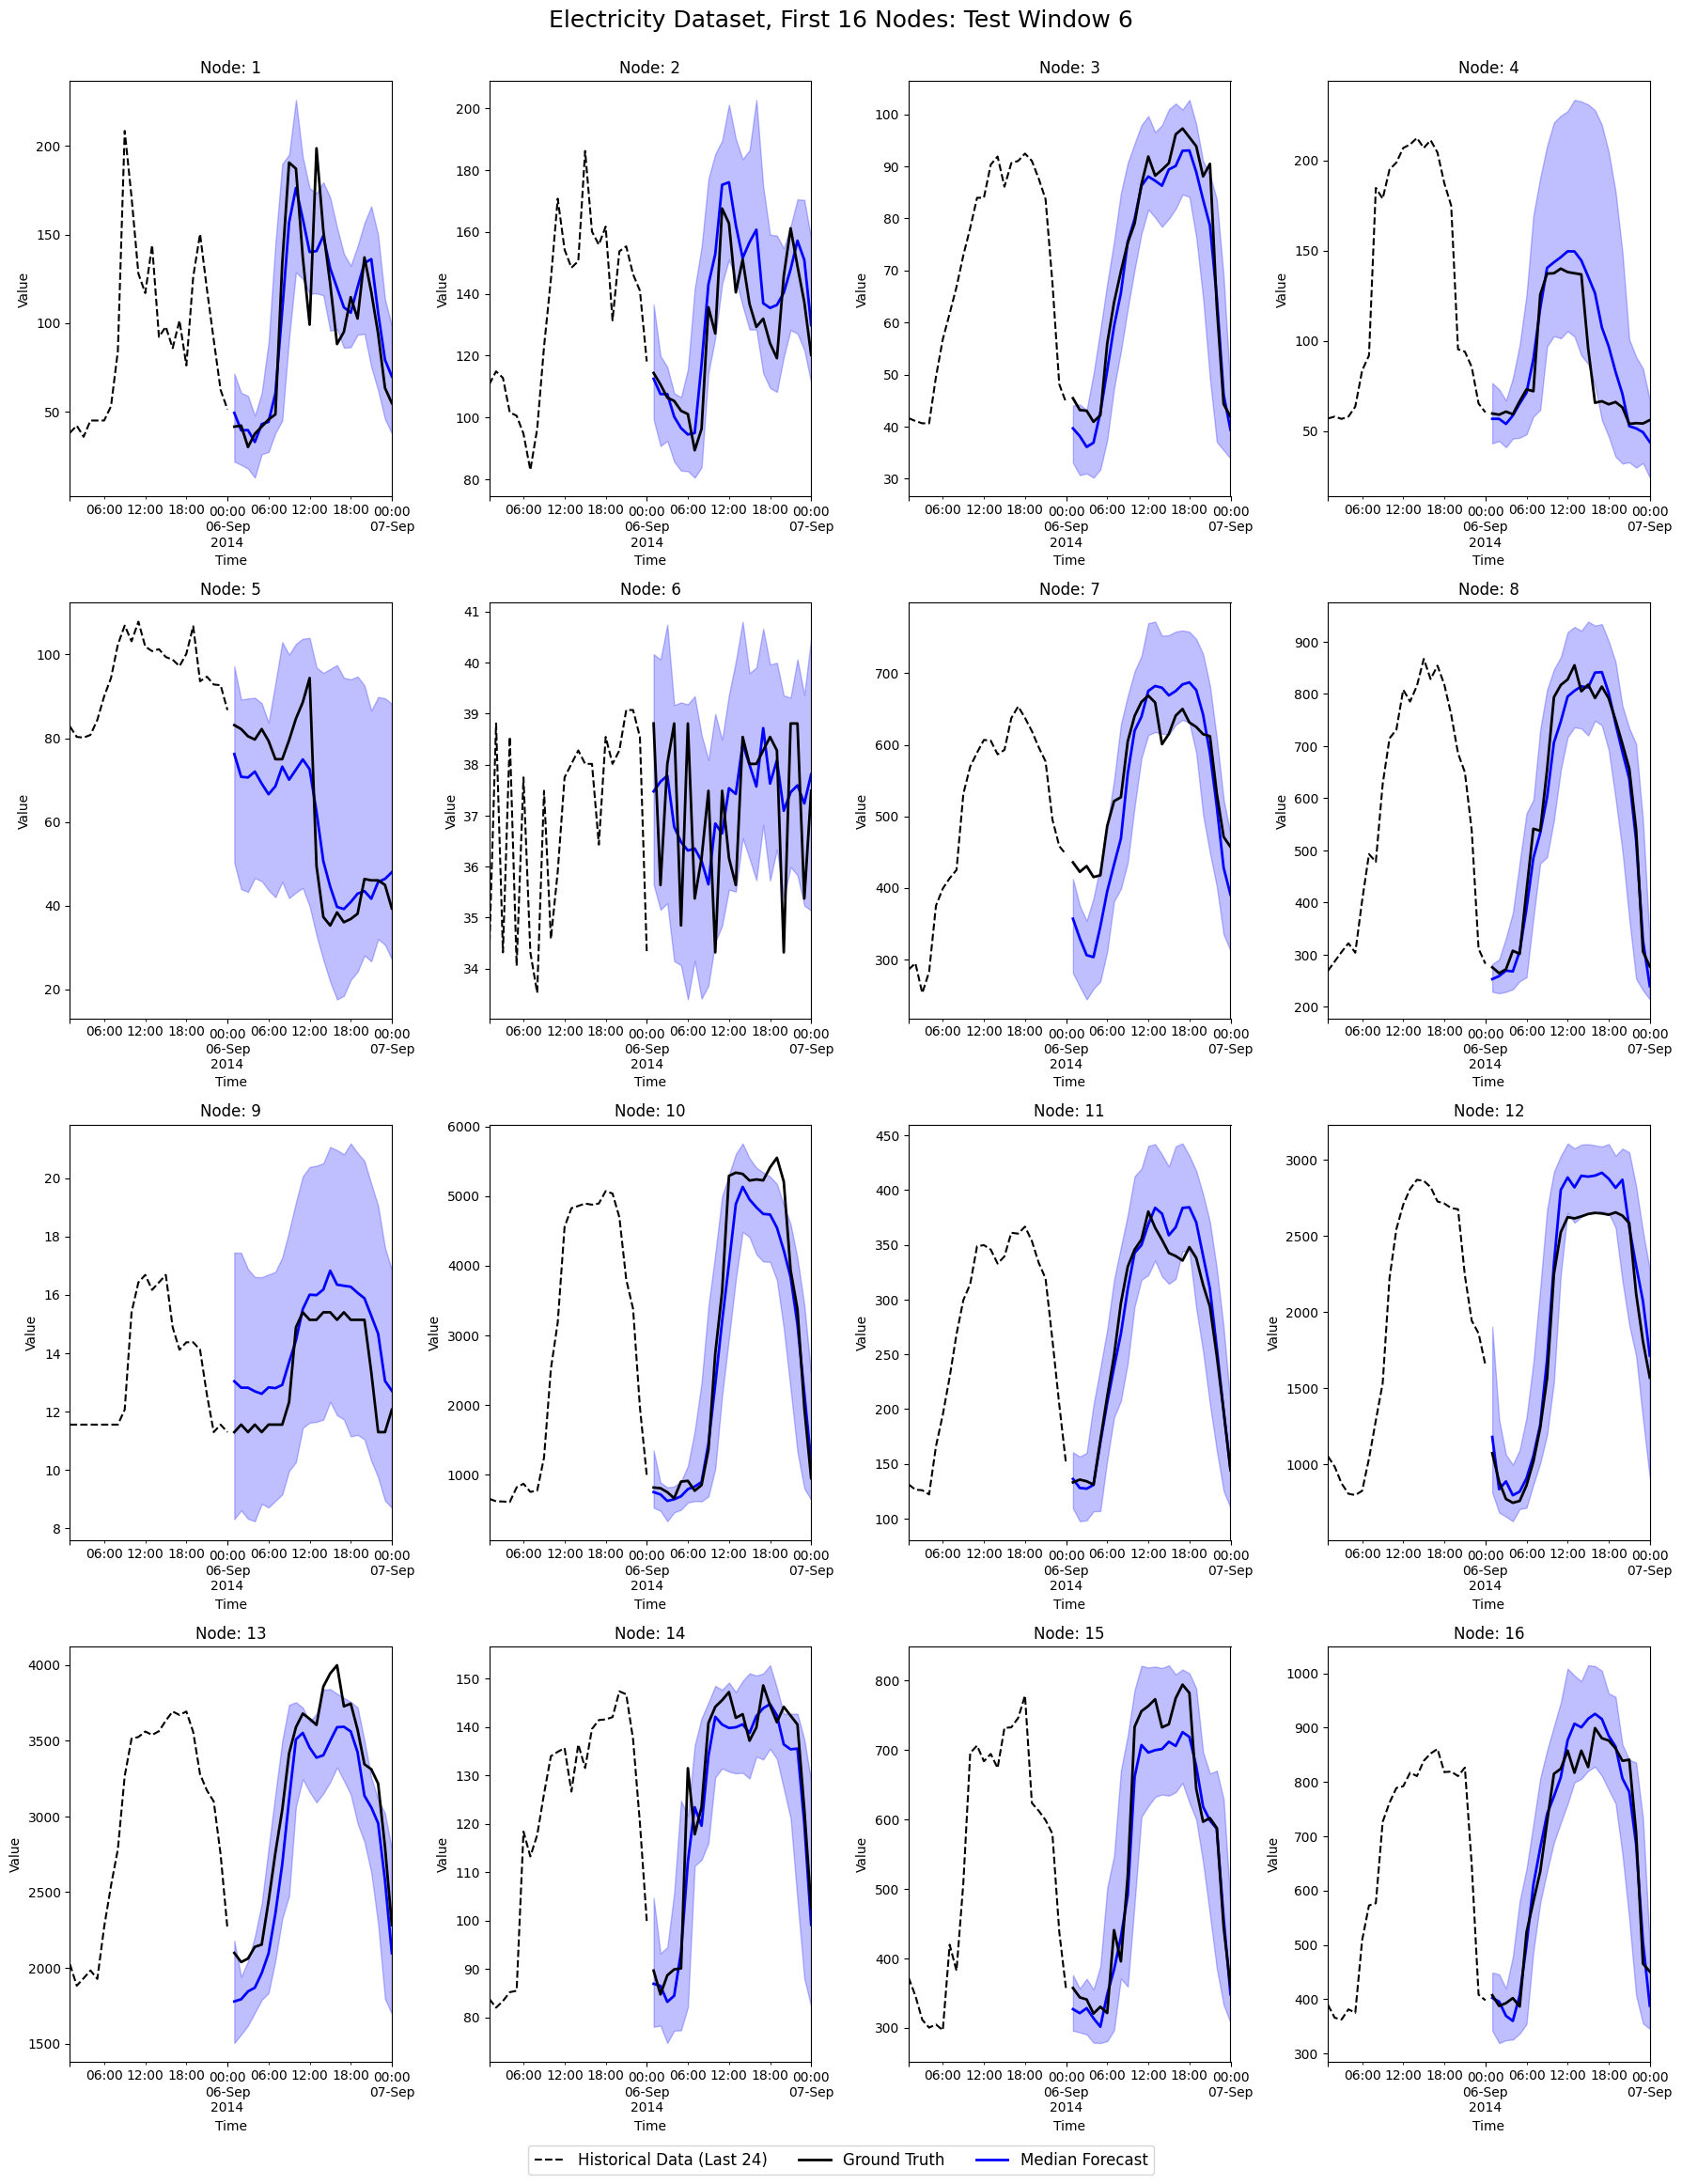

In [34]:
import matplotlib.pyplot as plt
lags = LAGS
pred_len=24
history_hours = 24
window_num = 5
full_ts = TimeSeries.from_dataframe(test_windows[window_num]).astype(np.float32)
full_sc = y_scaler.transform(full_ts).astype(np.float32)
full_pc = build_past_covs_552(full_sc, lags=lags).astype(np.float32)

full_sc = full_sc.slice_intersect(full_pc)
full_ts = full_ts.slice_intersect(full_sc)
full_pc = full_pc.slice_intersect(full_sc)

past_true_sc = full_sc[-2*pred_len:-pred_len]
gt_future    = full_ts[-pred_len:]

forecast_start = gt_future.start_time()          
pc_past = ts_upto(full_pc, forecast_start)      

#print(f"Past Values are {past_true_sc}")
model.model.encoder[0].reset_std(2)
model.model.encoder[0].reset_seed(208)
fc_sc = model.predict(pred_len, series=past_true_sc, past_covariates=pc_past, num_samples=100, verbose=False)
print(fc_sc.shape)
fc = y_scaler.inverse_transform(fc_sc)
#fc = fc.with_values(np.clip(fc.all_values(), a_min=0, a_max=None))

print(fc.shape)

forecast_unscaled = fc

# Ensure training data is also unscaled for plotting
# 'train' should be your original unscaled training TimeSeries
train_unscaled = full_ts[-2*pred_len:-pred_len]
actual_unscaled = gt_future

first_10_names = list(forecast_unscaled.components[:16])

# Subsetting
forecast_sub = forecast_unscaled[first_10_names]
actual_sub = actual_unscaled[first_10_names]
train_sub = train_unscaled[first_10_names]

import matplotlib.pyplot as plt

# 1. Enforce default matplotlib style
plt.style.use('default')

# Create figure and axes explicitly to manage the layout better
fig, axes = plt.subplots(4, 4, figsize=(18, 25))
axes = axes.flatten()

# Add a main title to the overall figure
fig.suptitle(f"Electricity Dataset, First 16 Nodes: Test Window {window_num+1}", fontsize=18, y=0.96)

for i in range(16):
    ax = axes[i]
    plt.sca(ax)  # Set current axis for Darts
    
    # Plot Last 24 points of Training Data
    train_sub.univariate_component(i).plot(
        label="Historical Data (Last 24)", 
        color="black", 
        linestyle="--", 
        linewidth=1.5
    )
    
    # Plot Ground Truth (Actuals)
    actual_sub.univariate_component(i).plot(
        label="Ground Truth", 
        color="black", 
        linewidth=2,
        zorder=10 
    )
    
    # Forecast Layer: 95% CI + Median
    forecast_sub.univariate_component(i).plot(
        central_quantile=0.5,    
        low_quantile=0.025,      # 2.5th percentile
        high_quantile=0.975,     # 97.5th percentile
        label="Median Forecast", # Updated label
        color="blue",
        alpha=0.25                # Single interval with 0.3 opacity
    )
    
    ax.set_title(f"Node: {i+1}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    
    # Darts sometimes automatically adds a legend; we remove it here to keep subplots clean
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# 2. Extract handles and labels for the unified legend
handles, labels = ax.get_legend_handles_labels()

# Deduplicate in case multiple calls generated duplicate labels
by_label = dict(zip(labels, handles))

# 3. Create a single figure-level legend at the bottom center
fig.legend(
    by_label.values(), 
    by_label.keys(), 
    loc='lower center', 
    ncol=3,                     # Reduced to 3 columns to match the 3 legend items
    fontsize='large', 
    bbox_to_anchor=(0.5, 0.035) 
)

# 4. Adjust layout
plt.tight_layout(rect=[0, 0.05, 1, 0.96]) 
plt.savefig("Electricity_Forecasts.pdf", format='pdf')
plt.show()

In [29]:
len(test_windows)

7

In [17]:
start = time.time()
lst = []
for i in range(10):
   lst.append(get_crps(model, test_windows, y_scaler, seed = SEED+i, std = 1))
end = time.time()
print(np.mean(lst), "$\pm$", np.std(lst))
print("Inference time:", (end-start))

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_55/3811171424.py:6: SyntaxWarning: invalid escape sequence '\p'
  print(np.mean(lst), "$\pm$", np.std(lst))


0.022562122875284116 $\pm$ 0.0003598196041827685
Inference time: 21.189536571502686


In [36]:
lst = []
seeds = [208, 234, 475, 209, 395, 110, 421,  12, 458, 251]
from tqdm import tqdm
for i in tqdm(seeds):
   lst.append(get_crps(model, test_windows, y_scaler, seed = i, lags=LAGS, std = 1))
print(np.mean(lst), 'pm', np.std(lst))
#np.argsort(lst)

100%|██████████| 500/500 [16:55<00:00,  2.03s/it]


array([208, 234, 475, 209, 395, 110, 421,  12, 458, 251, 280, 431, 103,
        20, 302, 283, 363,  28, 199, 291, 272, 238, 105, 350, 425, 213,
       182, 462,  48, 308, 247, 375, 255, 135, 493, 408,  32, 292, 207,
       322, 284, 163, 490,  49, 228, 288, 424, 224, 155, 333, 309, 127,
        74, 219,  80,  14, 253, 267, 189, 152,  63, 313, 147,  82,  73,
       383, 297, 479, 153, 205, 443, 444, 336, 148, 352,  15, 298, 274,
       159, 145, 387, 373,  90, 357,  27, 117, 179, 281, 390,   1, 237,
       319, 172, 222,  13, 362,  68,  89, 113, 146, 414, 321,  71, 188,
       393, 403, 236,  24,  38,  85, 360, 384, 427, 132, 328, 487, 278,
       235, 137, 470, 478, 484,  50, 115, 371, 491, 109, 158, 439, 161,
       483,  58, 389, 289, 265, 365, 367, 197, 305, 448, 114, 160, 481,
       435, 259, 377, 173,  55, 303, 170, 452, 269,  22, 338,  66, 270,
       133,   4,  25, 436, 407, 382, 465, 154, 455, 223, 344, 402, 124,
       244, 227,  95, 301, 186, 260, 273,   0, 174, 245, 405,  9

In [36]:
lst = []
for i in range(42,52):
   lst.append(get_crps(model, test_windows, y_scaler, seed = i, std = 1))
print(np.mean(lst), "$\pm$", np.std(lst))

0.03988193191519538 $\pm$ 0.00080241998279396


## Optimization

In [27]:
import optuna
import torch
import gc
from pytorch_lightning import seed_everything
import logging
import warnings
warnings.filterwarnings('ignore')


WORKING_DB_PATH = "/kaggle/working/entransformer_electricity_optuna.db"

if os.path.exists(WORKING_DB_PATH):
    print("Optuna database already exists in working directory. Resuming...")
else:
    print("No existing Optuna database found. Starting a brand new study...")


def objective(trial):
    SEED = 42
    deterministic.init_all(SEED)
    pl.seed_everything(SEED, workers=True)
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=False)
    
    # 1. Suggest Hyperparameters
    # Transformer architecture
    nhead = trial.suggest_int('nhead', 2, 16, 2)
    
    # Ensure d_model is divisible by nhead to prevent PyTorch crashes
    d_model_multiplier = trial.suggest_int('d_model_multiplier', 8, 24)
    d_model = nhead * d_model_multiplier 
    
    num_encoder_layers = trial.suggest_int('num_encoder_layers', 1, 4)
    #num_decoder_layers = trial.suggest_int('num_decoder_layers', 1, 4)
    dim_feedforward = trial.suggest_int('dim_feedforward', 128, 1024, 128)
    dropout = trial.suggest_float('dropout', 0.0, 0.4)
    activation = trial.suggest_categorical('activation', ['GLU', 'Bilinear', 'ReGLU', 'GEGLU', 'SwiGLU', 'ReLU', 'GELU', 'relu', 'gelu'])
    
    # Training parameters
    lr = trial.suggest_float('lr', 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    noise_dist = trial.suggest_categorical('noise_dist', ['uniform', 'gaussian'])
    
    # Engression specific parameters
    noise_std = trial.suggest_float('noise_std', 0.5, 2.0)
    num_samples_engression = trial.suggest_int('num_samples_engression', 2, 8)

    # 3. Initialize Model with suggested parameters
    model = EnTransformerModel(
        input_chunk_length=24,
        output_chunk_length=24,
        num_samples_engression=num_samples_engression,
        noise_std=noise_std,
        d_model=d_model,
        optimizer_kwargs={'lr': lr},
        output_chunk_shift=0, 
        nhead=nhead, 
        num_encoder_layers=num_encoder_layers,
        num_decoder_layers=num_encoder_layers, 
        dim_feedforward=dim_feedforward, 
        dropout=dropout, 
        activation=activation, 
        batch_size=batch_size, 
        n_epochs=30, # Consider using fewer epochs during tuning to save time
        noise_dist=noise_dist
    )

    # 4. Fit the model
    # Set verbose=False 
    model.fit(train_y_sc, past_covariates=train_pc, verbose=True)

    # 5. Evaluate the model
    # get_crps_sum returns a score we want to MINIMIZE
    scores = []
    for i in range(10):
        scores.append(get_crps(model, test_windows, y_scaler, seed=SEED+i, std=noise_std))
    crps_score = np.mean(scores)

    # 6. Memory Management (Crucial when tuning PyTorch models in a loop)
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return crps_score

def print_crps_callback(study, trial):
    # This runs immediately after the trial returns its score
    print(f"Trial {trial.number} Finished, Current CRPS: {trial.value:.4f}, Best CRPS so far: {study.best_value:.4f}")


# 7. Create and run the Optuna study
if __name__ == "__main__":
    # Create study optimizing for the lowest CRPS sum
    storage_name = f"sqlite:///{WORKING_DB_PATH}"
    study = optuna.create_study(direction='minimize', study_name="EnTransformer_Electricity_Tuning", storage=storage_name,              
        load_if_exists=True)
    
    # Run the optimization WITH the custom callback
    study.optimize(objective, n_trials=200, callbacks=[print_crps_callback], n_jobs=1)

    print("\n=== Hyperparameter Tuning Completed ===")
    print(f"Best CRPS Score: {study.best_value}")
    print("Best Hyperparameters:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")
        
    # Optional: Reconstruct actual d_model for the final parameters
    best_d_model = study.best_params['nhead'] * study.best_params['d_model_multiplier']
    print(f"  --> calculated d_model: {best_d_model}")

[I 2026-03-08 10:55:24,644] Using an existing study with name 'EnTransformer_Electricity_Tuning' instead of creating a new one.
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Optuna database already exists in working directory. Resuming...


Training: |          | 0/? [00:00<?, ?it/s]

[I 2026-03-08 11:00:19,613] Trial 107 finished with value: 0.06039309085862528 and parameters: {'nhead': 10, 'd_model_multiplier': 13, 'num_encoder_layers': 2, 'dim_feedforward': 1024, 'dropout': 0.02306427327951023, 'activation': 'SwiGLU', 'lr': 0.0010420411205942855, 'batch_size': 64, 'noise_dist': 'uniform', 'noise_std': 1.2976479069987663, 'num_samples_engression': 8}. Best is trial 98 with value: 0.0264381037047045.
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Trial 107 Finished, Current CRPS: 0.0604, Best CRPS so far: 0.0264


...

[I 2026-03-08 16:50:04,238] Trial 174 finished with value: 0.03948242641248425 and parameters: {'nhead': 12, 'd_model_multiplier': 12, 'num_encoder_layers': 2, 'dim_feedforward': 384, 'dropout': 0.022943234735216936, 'activation': 'SwiGLU', 'lr': 0.00034486863150288164, 'batch_size': 32, 'noise_dist': 'uniform', 'noise_std': 1.38664464940629, 'num_samples_engression': 8}. Best is trial 119 with value: 0.02331255790621.
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Trial 174 Finished, Current CRPS: 0.0395, Best CRPS so far: 0.0233


Training: |          | 0/? [00:00<?, ?it/s]

[W 2026-03-08 16:52:32,311] Trial 175 failed with parameters: {'nhead': 12, 'd_model_multiplier': 10, 'num_encoder_layers': 2, 'dim_feedforward': 896, 'dropout': 0.049309947919358596, 'activation': 'Bilinear', 'lr': 0.00120489624464448, 'batch_size': 32, 'noise_dist': 'uniform', 'noise_std': 1.115977892693673, 'num_samples_engression': 7} because of the following error: NameError("name 'exit' is not defined").
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/call.py", line 48, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 599, in _fit_impl
    self._run(model, ckpt_path=ckpt_path)
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1012, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/pytho

NameError: name 'exit' is not defined

In [28]:
import optuna
import torch
import gc
from pytorch_lightning import seed_everything
import logging
import warnings
warnings.filterwarnings('ignore')


WORKING_DB_PATH = "/kaggle/working/entransformer_electricity_optuna2.db"

if os.path.exists(WORKING_DB_PATH):
    print("Optuna database already exists in working directory. Resuming...")
else:
    print("No existing Optuna database found. Starting a brand new study...")


def objective(trial):
    SEED = 42
    deterministic.init_all(SEED)
    pl.seed_everything(SEED, workers=True)
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=False)
    
    # 1. Suggest Hyperparameters
    # Transformer architecture
    nhead = trial.suggest_int('nhead', 2, 16, 2)
    
    # Ensure d_model is divisible by nhead to prevent PyTorch crashes
    d_model_multiplier = trial.suggest_int('d_model_multiplier', 8, 24)
    d_model = nhead * d_model_multiplier 
    
    num_encoder_layers = trial.suggest_int('num_encoder_layers', 1, 4)
    #num_decoder_layers = trial.suggest_int('num_decoder_layers', 1, 4)
    dim_feedforward = trial.suggest_int('dim_feedforward', 128, 1024, 128)
    dropout = trial.suggest_float('dropout', 0.0, 0.4)
    activation = trial.suggest_categorical('activation', ['GLU', 'Bilinear', 'ReGLU', 'GEGLU', 'SwiGLU', 'ReLU', 'GELU', 'relu', 'gelu'])
    
    # Training parameters
    lr = trial.suggest_float('lr', 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    noise_dist = trial.suggest_categorical('noise_dist', ['uniform', 'gaussian'])
    
    # Engression specific parameters
    noise_std = trial.suggest_float('noise_std', 0.5, 2.0)
    num_samples_engression = trial.suggest_int('num_samples_engression', 2, 8)

    # 3. Initialize Model with suggested parameters
    model = EnTransformerModel(
        input_chunk_length=24,
        output_chunk_length=24,
        num_samples_engression=num_samples_engression,
        noise_std=noise_std,
        d_model=d_model,
        optimizer_kwargs={'lr': lr},
        output_chunk_shift=0, 
        nhead=nhead, 
        num_encoder_layers=num_encoder_layers,
        num_decoder_layers=num_encoder_layers, 
        dim_feedforward=dim_feedforward, 
        dropout=dropout, 
        activation=activation, 
        batch_size=batch_size, 
        n_epochs=30, # Consider using fewer epochs during tuning to save time
        noise_dist=noise_dist
    )

    # 4. Fit the model
    # Set verbose=False 
    model.fit(train_y_sc, past_covariates=train_pc, verbose=True)

    # 5. Evaluate the model
    # get_crps_sum returns a score we want to MINIMIZE
    scores = []
    for i in range(10):
        scores.append(get_crps(model, test_windows, y_scaler, seed=SEED+i, std=noise_std))
    crps_score = np.mean(scores)

    # 6. Memory Management (Crucial when tuning PyTorch models in a loop)
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return crps_score

def print_crps_callback(study, trial):
    # This runs immediately after the trial returns its score
    print(f"Trial {trial.number} Finished, Current CRPS: {trial.value:.4f}, Best CRPS so far: {study.best_value:.4f}")


# 7. Create and run the Optuna study
if __name__ == "__main__":
    # Create study optimizing for the lowest CRPS sum
    storage_name = f"sqlite:///{WORKING_DB_PATH}"
    study = optuna.create_study(direction='minimize', study_name="EnTransformer_Electricity_Tuning2", storage=storage_name,              
        load_if_exists=True)
    
    # Run the optimization WITH the custom callback
    study.optimize(objective, n_trials=200, callbacks=[print_crps_callback], n_jobs=1)

    print("\n=== Hyperparameter Tuning Completed ===")
    print(f"Best CRPS Score: {study.best_value}")
    print("Best Hyperparameters:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")
        
    # Optional: Reconstruct actual d_model for the final parameters
    best_d_model = study.best_params['nhead'] * study.best_params['d_model_multiplier']
    print(f"  --> calculated d_model: {best_d_model}")

[I 2026-03-08 16:52:59,221] A new study created in RDB with name: EnTransformer_Electricity_Tuning2
INFO: Seed set to 42


No existing Optuna database found. Starting a brand new study...


INFO:lightning.fabric.utilities.seed:Seed set to 42


Training: |          | 0/? [00:00<?, ?it/s]

[I 2026-03-08 16:55:11,693] Trial 0 finished with value: 0.07439813156078004 and parameters: {'nhead': 4, 'd_model_multiplier': 20, 'num_encoder_layers': 3, 'dim_feedforward': 1024, 'dropout': 0.38898508289916445, 'activation': 'SwiGLU', 'lr': 0.021607583253932004, 'batch_size': 128, 'noise_dist': 'uniform', 'noise_std': 1.0298982921850495, 'num_samples_engression': 2}. Best is trial 0 with value: 0.07439813156078004.
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


...

[I 2026-03-08 17:02:57,008] Trial 1 finished with value: 0.35948121899964897 and parameters: {'nhead': 16, 'd_model_multiplier': 19, 'num_encoder_layers': 4, 'dim_feedforward': 1024, 'dropout': 0.10158797891996373, 'activation': 'Bilinear', 'lr': 0.004358609084641672, 'batch_size': 32, 'noise_dist': 'gaussian', 'noise_std': 1.973325608665896, 'num_samples_engression': 2}. Best is trial 0 with value: 0.07439813156078004.
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Trial 1 Finished, Current CRPS: 0.3595, Best CRPS so far: 0.0744


Training: |          | 0/? [00:00<?, ?it/s]

[W 2026-03-08 17:03:38,768] Trial 2 failed with parameters: {'nhead': 6, 'd_model_multiplier': 17, 'num_encoder_layers': 4, 'dim_feedforward': 384, 'dropout': 0.3463524850989899, 'activation': 'relu', 'lr': 0.0074096861553475755, 'batch_size': 128, 'noise_dist': 'uniform', 'noise_std': 1.2825074414298556, 'num_samples_engression': 4} because of the following error: NameError("name 'exit' is not defined").
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/call.py", line 48, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 599, in _fit_impl
    self._run(model, ckpt_path=ckpt_path)
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1012, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12

NameError: name 'exit' is not defined

In [ ]:
import pickle
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
import numpy as np

# --- 1. Fixed Search Space ---
search_space = {
    "n_heads": hp.quniform("n_heads", 2, 8, 2),
    "head_dim": hp.quniform("head_dim", 2, 64, 2),
    "n_coder_layers": hp.choice("n_coder_layers", [3, 5, 8]),
    "std": hp.uniform("std", 0.5, 3.0),
    "engression_m": hp.quniform("engression_m", 2, 8, 2), 
    "dim_feed_forward": hp.quniform("dim_feed_forward", 32, 512, 32),
    "learning_rate": hp.qloguniform("learning_rate", np.log(1e-5), np.log(1e-2), 1e-5),
    "dropout": hp.quniform("dropout", 0.0, 0.5, 0.05),
    "batch_size": hp.quniform("batch_size", 32, 128, 32),
    "activation_fn": hp.choice("activation_fn" ,['GLU', 'Bilinear', 'ReGLU', 'GEGLU', 'SwiGLU', 'ReLU', 'GELU', 'relu', 'gelu']),
    "prediction_std" : hp.uniform("prediction_std", 0.5, 3.0),
}

# --- 2. Fixed Objective Function ---
def objective(params):

    SEED = 42
    deterministic.init_all(SEED)
    pl.seed_everything(SEED, workers=True)
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=False)
    # Initialize Engression Transformer
    n_heads = int(params['n_heads'])
    head_dim = int(params['head_dim'])
    hidden_size = n_heads * head_dim  
    activation_fn = params["activation_fn"]
    
    # Force everything to correct types
    n_coder = int(params['n_coder_layers'])

    
    try:
        model = EnTransformerModel(
            input_chunk_length=24,
            output_chunk_length=24,
            nhead=n_heads,
            d_model=hidden_size, 
            noise_std=params['std'],
            num_samples_engression=int(params['engression_m']),
            optimizer_kwargs={'lr': params['learning_rate']}, # Fixed = to :
            dropout=params['dropout'],
            output_chunk_shift=0,
            num_decoder_layers=n_coder,
            num_encoder_layers=n_coder,
            dim_feedforward=int(params['dim_feed_forward']),
            activation=activation_fn,
            batch_size=int(params['batch_size']),
            random_state = SEED,
            n_epochs = 30,
            noise_dist="uniform"
        )

        model.fit(train_y_sc, past_covariates=train_pc, verbose=True, dataloader_kwargs={"num_workers": 0})
        crps_list = []
        for i in range(10):
            crps_list.append((get_crps(model , test_windows, y_scaler, seed = SEED + i, std = params['prediction_std'])))
        mean_crps = np.mean(crps_list)
        std_crps = np.std(crps_list)
        print(f"Got Result {mean_crps} +/- {std_crps} for {params}")

        return {"loss": mean_crps, "status": STATUS_OK, 'crps_list' : crps_list}
    
    except Exception as e:
        print(f"Trial failed: {e}")
        return {"loss": 1e6, "status": STATUS_OK} # Return high loss on fail

# --- 3. The Run Loop (Saving every 5 runs) ---
trials_step = 5
max_trials = 50 # Total runs you want
trials_file = "hyperopt_trials_7marchsolarv3.pkl"

# Try to load existing trials if you are restarting
try:
    with open(trials_file, "rb") as f:
        trials = pickle.load(f)
    print(f"Found existing trials. Resuming from {len(trials.trials)} runs.")
except:
    trials = Trials()

for i in range(len(trials.trials) + trials_step, max_trials + trials_step, trials_step):
    best = fmin(
        fn=objective,
        space=search_space,
        algo=tpe.suggest,
        max_evals=i,
        trials=trials,
        rstate = np.random.default_rng(SEED)
    )
    
    # Save the trials object
    with open(trials_file, "wb") as f:
        pickle.dump(trials, f)
    
    print(f"Checkpoint saved at {i} trials. Best so far: {best}")